# Buổi 5 (mở rộng) — Từ Adaline/Widrow–Hoff đến MLP

Notebook này nối tiếp `05_adaline_cit.ipynb`: nhắc lại nhanh Adaline trên C/I/T bằng quy tắc Widrow–Hoff (LMS), huấn luyện nhiều epoch, áp dụng vào một bài toán thực tế (cảnh báo máy quá tải), rồi mở rộng sang MLP một lớp ẩn để thấy backpropagation chính là Widrow–Hoff được nối dài qua quy tắc dây chuyền.

Quy trình gợi ý: đọc công thức → chạy code → quan sát số liệu in ra → đọc phần giải thích để chốt lại ý nghĩa.

## 1. Adaline khác Perceptron ở đâu?

Perceptron cho đầu ra 0/1 sau hàm bước, nên chỉ biết đúng hay sai. Adaline dùng chính giá trị tuyến tính làm đầu ra:

$$
y = \text{net} = \mathbf{w}^\top \mathbf{x} + b
$$

Sai số được tính bằng:

$$
e = t - \text{net}
$$

Hàm lỗi tức thời:

$$
E = \frac{1}{2}(t-\text{net})^2
$$

Quy tắc Widrow–Hoff (LMS):

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e\mathbf{x}, \qquad b \leftarrow b + \eta e
$$

- Perceptron chỉ biết "sai hay đúng".
- Adaline biết "sai bao nhiêu", vì sai số là một số thực liên tục.
- Chính chỗ này là cây cầu từ Perceptron sang gradient descent và sau đó là backpropagation trong MLP.

## 2. Dữ liệu C–I–T: giữ nguyên ví dụ của buổi 5

Mã hóa 5 feature cho ba chữ:

- $x_1$: có nét dọc bên trái
- $x_2$: có nét dọc bên phải
- $x_3$: có nét ngang phía trên
- $x_4$: có nét ngang phía dưới
- $x_5$: có nét dọc ở giữa

Target: C → 1, I → 0, T → 0.

In [22]:
import numpy as np
import pandas as pd
from IPython.display import display

X_cit = np.array([
    [1, 0, 1, 1, 0],  # C
    [0, 0, 1, 1, 1],  # I
    [0, 0, 1, 0, 1],  # T
], dtype=float)

t_cit = np.array([1.0, 0.0, 0.0])

print("X_cit =")
print(X_cit)
print("t_cit =", t_cit)

X_cit =
[[1. 0. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 0. 1.]]
t_cit = [1. 0. 0.]


Dữ liệu này giữ đúng như bài giảng để nối được từ bảng tính tay sang thực nghiệm trong notebook. Khi không đổi ví dụ quá sớm, ta tập trung vào bản chất của quy tắc học thay vì bị nhiễu bởi ngữ cảnh mới.

## 3. Khởi tạo Adaline và giải thích từng biến

- `eta`: learning rate (tốc độ học), quyết định mức độ lớn của mỗi lần cập nhật trọng số.
- `w`: vector trọng số.
- `b`: bias.

`eta = 0.1` được chọn như một giá trị minh họa vừa phải:
- Nếu `eta` quá nhỏ, mô hình học rất chậm và cần nhiều epoch.
- Nếu `eta` quá lớn, trọng số có thể thay đổi quá mạnh, khiến lỗi dao động hoặc khó hội tụ.
- Với dữ liệu đầu vào đã được mã hóa ở mức nhỏ như C–I–T, `0.1` giúp nhìn rõ sự thay đổi sau từng bước mà vẫn tương đối ổn định.
Giá trị `0.1` không phải là hằng số bắt buộc. Trong bài toán thực tế, cần thử nhiều giá trị như `0.01`, `0.05`, `0.1` hoặc `0.5` và chọn giá trị cho quá trình học ổn định, MSE giảm tốt.


Khởi tạo tất cả bằng 0 nghĩa là mạng chưa ưu tiên feature nào. Với ví dụ nhập môn, tính dễ theo dõi quan trọng hơn khởi tạo ngẫu nhiên.

In [23]:
eta = 0.1
w = np.zeros(5)
b = 0.0

print("eta =", eta)
print("w0 =", w)
print("b0 =", b)

eta = 0.1
w0 = [0. 0. 0. 0. 0.]
b0 = 0.0


## 4. Viết hàm một bước Adaline rõ từng phép toán

Cell dưới là trái tim của notebook: biến công thức toán thành mã lệnh một–một — tính `net`, tính sai số, tính độ chỉnh, rồi cập nhật. Đây cũng là điểm cần hiểu thật chắc trước khi học backpropagation ở MLP.

In [24]:
def step_adaline(x, t, w, b, eta):
    # Bước 1: tính từng tích w_i * x_i
    products = w * x

    # Bước 2: cộng các tích và cộng bias
    weighted_sum = np.sum(products)
    net = weighted_sum + b

    # Bước 3: tính sai số
    e = t - net

    # Bước 4: tính độ điều chỉnh cho từng trọng số
    delta_w = eta * e * x
    delta_b = eta * e

    # Bước 5: cập nhật trọng số và bias
    w_new = w + delta_w
    b_new = b + delta_b

    details = pd.DataFrame({
        "Feature": [f"x{i + 1}" for i in range(len(x))],
        "x_i": x,
        "w_i": w,
        "w_i * x_i": products,
        "Delta w_i": delta_w,
        "w_i mới": w_new
    })

    summary = pd.DataFrame({
        "Đại lượng": [
            "Tổng Σ(w_i*x_i)",
            "Bias cũ",
            "Net = Σ(w_i*x_i) + b",
            "Target t",
            "Sai số e = t - Net",
            "Learning rate eta",
            "Delta bias",
            "Bias mới"
        ],
        "Giá trị": [
            weighted_sum, b, net, t, e, eta, delta_b, b_new
        ]
    })

    display(summary)
    display(details)

    return net, e, w_new, b_new

## 5. Tính tay bằng code: chạy lần lượt C, I, T trong 1 epoch

Kết quả cuối epoch 1 phải khớp với bài giảng buổi 5: $w = (0.1,\ 0,\ 0.059,\ 0.07,\ -0.041)$, $b \approx 0.059$.

Trực giác:
- $w_1$ dương lớn vì nét dọc trái là tín hiệu mạnh của chữ C.
- $w_5$ âm vì nét dọc giữa thường xuất hiện ở I và T, không thuận cho chữ C.

In [25]:
w = np.zeros(5)
b = 0.0

for i, (x, t) in enumerate(zip(X_cit, t_cit), start=1):
    print(f"BƯỚC {i}")
    net, e, w, b = step_adaline(x, t, w, b, eta)

print("w sau epoch 1 =", w)
print("b sau epoch 1 =", b)

BƯỚC 1


,Đại lượng,Giá trị
0,Tổng Σ(w_i*x_i),0.0
1,Bias cũ,0.0
2,Net = Σ(w_i*x_i) + b,0.0
3,Target t,1.0
4,Sai số e = t - Net,1.0
5,Learning rate eta,0.1
6,Delta bias,0.1
7,Bias mới,0.1


,Feature,x_i,w_i,w_i * x_i,Delta w_i,w_i mới
0,x1,1.0,0.0,0.0,0.1,0.1
1,x2,0.0,0.0,0.0,0.0,0.0
2,x3,1.0,0.0,0.0,0.1,0.1
3,x4,1.0,0.0,0.0,0.1,0.1
4,x5,0.0,0.0,0.0,0.0,0.0


BƯỚC 2


,Đại lượng,Giá trị
0,Tổng Σ(w_i*x_i),0.20
1,Bias cũ,0.10
2,Net = Σ(w_i*x_i) + b,0.30
3,Target t,0.00
4,Sai số e = t - Net,-0.30
5,Learning rate eta,0.10
6,Delta bias,-0.03
7,Bias mới,0.07


,Feature,x_i,w_i,w_i * x_i,Delta w_i,w_i mới
0,x1,0.0,0.1,0.0,-0.00,0.10
1,x2,0.0,0.0,0.0,-0.00,0.00
2,x3,1.0,0.1,0.1,-0.03,0.07
3,x4,1.0,0.1,0.1,-0.03,0.07
4,x5,1.0,0.0,0.0,-0.03,-0.03


BƯỚC 3


,Đại lượng,Giá trị
0,Tổng Σ(w_i*x_i),0.040
1,Bias cũ,0.070
2,Net = Σ(w_i*x_i) + b,0.110
3,Target t,0.000
4,Sai số e = t - Net,-0.110
5,Learning rate eta,0.100
6,Delta bias,-0.011
7,Bias mới,0.059


,Feature,x_i,w_i,w_i * x_i,Delta w_i,w_i mới
0,x1,0.0,0.10,0.00,-0.000,0.100
1,x2,0.0,0.00,0.00,-0.000,0.000
2,x3,1.0,0.07,0.07,-0.011,0.059
3,x4,0.0,0.07,0.00,-0.000,0.070
4,x5,1.0,-0.03,-0.03,-0.011,-0.041


w sau epoch 1 = [ 0.1    0.     0.059  0.07  -0.041]
b sau epoch 1 = 0.059000000000000004


## 6. Kiểm tra lại toàn bộ dữ liệu và tính MSE

Đây là bước "khép Widrow–Hoff bằng thực nghiệm": không chỉ sửa sau từng mẫu mà còn quay lại nhìn chất lượng trên toàn bộ dữ liệu bằng MSE. Khi MSE giảm dần qua epoch, ta thấy rõ ý nghĩa của tối ưu hóa sai số bình phương trung bình.

In [26]:
def mse(X, t, w, b):
    nets = X @ w + b
    errors = t - nets
    E = 0.5 * errors**2
    return E.mean(), nets, errors

E_cit, nets_cit, errors_cit = mse(X_cit, t_cit, w, b)
print("nets   =", nets_cit)
print("errors =", errors_cit)
print("MSE    =", E_cit)

nets   = [0.288 0.147 0.077]
errors = [ 0.712 -0.147 -0.077]
MSE    = 0.08908033333333332


## 7. Huấn luyện nhiều epoch và quan sát hội tụ

Nếu muốn tránh quá nhiều dòng in ra màn hình, có thể bỏ `print` trong `step_adaline` khi sang phần huấn luyện nhiều epoch. Điều quan trọng là thấy từ "một bước cập nhật" chuyển thành "một đường học" theo thời gian.

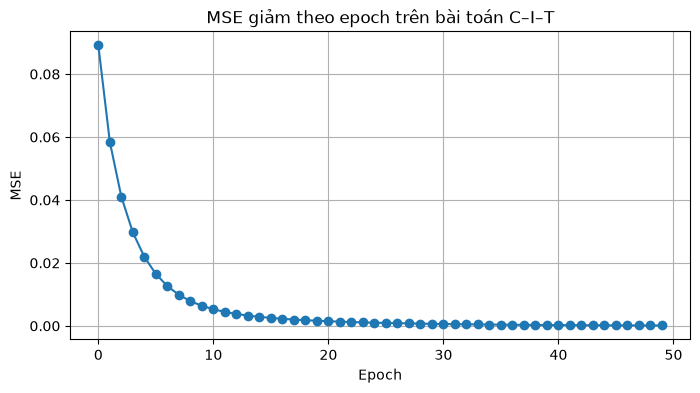

In [27]:
import matplotlib.pyplot as plt

w = np.zeros(5)
b = 0.0
n_epochs = 50
mse_hist = []

for epoch in range(n_epochs):
    for x, tk in zip(X_cit, t_cit):
        net = np.dot(w, x) + b
        e = tk - net
        w = w + eta * e * x
        b = b + eta * e
    E, _, _ = mse(X_cit, t_cit, w, b)
    mse_hist.append(E)

plt.figure(figsize=(8, 4))
plt.plot(mse_hist, marker='o')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE giảm theo epoch trên bài toán C–I–T")
plt.grid(True)
plt.show()

## 8. Tổng quát hóa thành class `Adaline`

Class này không thay đổi bản chất của toán học; nó chỉ đóng gói đúng mạch tính toán từ buổi 5 vào một cấu trúc dùng lại được. Đây là bước chuyển quan trọng từ "hiểu công thức" sang "xây mô hình có thể tái sử dụng".

In [28]:
class Adaline:
    def __init__(self, n_features, eta=0.1):
        self.eta = eta
        self.w = np.zeros(n_features)
        self.b = 0.0

    def forward(self, X):
        return X @ self.w + self.b

    def fit(self, X, t, n_epochs=50):
        history = []
        for epoch in range(n_epochs):
            for x, tk in zip(X, t):
                net = np.dot(self.w, x) + self.b
                e = tk - net
                self.w += self.eta * e * x
                self.b += self.eta * e
            E, _, _ = mse(X, t, self.w, self.b)
            history.append(E)
        return history

    def predict(self, X):
        return self.forward(X)

In [29]:
adaline_cit = Adaline(n_features=5, eta=0.1)
hist_cit = adaline_cit.fit(X_cit, t_cit, n_epochs=50)

print("w =", adaline_cit.w)
print("b =", adaline_cit.b)
print("du doan =", adaline_cit.predict(X_cit))

w = [ 0.57979982  0.          0.18856911  0.0345428  -0.39123071]
b = 0.18856910968004367
du doan = [ 0.99148084  0.02045031 -0.01409249]


## 9. Áp dụng vào tình huống thực tế: cảnh báo máy quá tải

Feature minh họa:

- $x_1$: CPU đã chuẩn hóa về $[0,1]$
- $x_2$: nhiệt độ đã chuẩn hóa về $[0,1]$
- $x_3$: độ dài hàng đợi công việc đã chuẩn hóa về $[0,1]$

Target $t$: điểm quá tải trong $[0,1]$.

In [30]:
X_load = np.array([
    [0.9, 0.8, 0.9],
    [0.3, 0.4, 0.2],
    [0.6, 0.5, 0.3],
], dtype=float)

t_load = np.array([0.9, 0.2, 0.5])

adaline_load = Adaline(n_features=3, eta=0.1)
hist_load = adaline_load.fit(X_load, t_load, n_epochs=100)

print("w load =", adaline_load.w)
print("b load =", adaline_load.b)

x_new = np.array([0.7, 0.6, 0.5])
y_new = adaline_load.predict(x_new)
print("Diem qua tai du doan =", y_new)

w load = [0.4441667  0.24022868 0.41616022]
b load = -0.057956727327732195
Diem qua tai du doan = 0.6051772841301334


Đây là chỗ nhận ra Adaline không chỉ học "giống chữ C bao nhiêu", mà còn học những điểm số liên tục trong thực tế như mức quá tải, phút trễ, lượng nước tưới hay giá nhà. Cùng một công thức LMS được tái sử dụng, chỉ thay dữ liệu và ý nghĩa của target.

Thảo luận ngắn:
- Nếu $y \ge 0.7$: cảnh báo vàng.
- Nếu $y \ge 0.9$: cảnh báo đỏ.
- Nhưng ngưỡng an toàn thật phải do rule cứng quyết định, không giao hoàn toàn cho mạng.

## 10. Cầu nối sang MLP: vì sao Adaline chưa đủ?

Adaline chỉ là một mô hình tuyến tính:

$$
y = \mathbf{w}^\top \mathbf{x} + b
$$

Nó phù hợp khi mối quan hệ giữa đầu vào và target gần tuyến tính.

Nhưng nếu bài toán có tương tác phi tuyến, ví dụ:
- CPU cao *và* nhiệt cao *và* hàng đợi dài mới thực sự nguy hiểm
- diện tích *và* vị trí cùng tác động đến giá nhà

thì một nơ-ron tuyến tính có thể không đủ. Adaline là "một lớp tính điểm trực tiếp từ input". MLP thêm lớp ẩn để học các tổ hợp feature mới, nhờ đó biểu diễn được quan hệ phức tạp hơn.

## 11. Giới thiệu nhanh MLP một lớp ẩn

Với MLP nhỏ, thay vì đi thẳng từ input ra output, ta có:

$$
\mathbf{z}^{(1)} = W^{(1)}\mathbf{x} + \mathbf{b}^{(1)}
$$
$$
\mathbf{h} = \sigma(\mathbf{z}^{(1)})
$$
$$
z^{(2)} = W^{(2)}\mathbf{h} + b^{(2)}
$$
$$
y = z^{(2)}
$$

- Lớp ẩn tạo ra biểu diễn mới $\mathbf{h}$.
- Lớp ra vẫn cho một giá trị liên tục để so với target.

In [31]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Vi du 3 input -> 3 hidden -> 1 output
np.random.seed(42)
W1 = np.random.randn(3, 3) * 0.1
b1 = np.zeros(3)
W2 = np.random.randn(3) * 0.1
b2 = 0.0

x = X_load[0]
t = t_load[0]

z1 = W1.T @ x + b1
h = sigmoid(z1)
z2 = W2 @ h + b2
y = z2
e = t - y

print("x =", x)
print("z1 =", z1)
print("h =", h)
print("z2 =", z2)
print("y =", y)
print("e =", e)

x = [0.9 0.8 0.9]
z1 = [ 0.30867582  0.03789307 -0.00269168]
h = [0.57656201 0.50947213 0.49932708]
z2 = -0.015583036933252446
y = -0.015583036933252446
e = 0.9155830369332525


Ở Adaline, input đi thẳng tới output. Ở MLP, input đi qua lớp ẩn, nên mạng có cơ hội học các kết hợp như "CPU cao + nhiệt cao" trước khi ra điểm cuối cùng.

## 12. Backpropagation là Widrow–Hoff mở rộng như thế nào?

Với Adaline:

$$
\Delta \mathbf{w} = \eta e\mathbf{x}
$$

Ý tưởng: nếu sai số còn lớn, hãy sửa trọng số theo hướng làm giảm sai số.

Với MLP, ta vẫn làm đúng tinh thần đó, nhưng sai số ở lớp ra phải truyền ngược vào các lớp trước bằng đạo hàm theo quy tắc dây chuyền.

- Adaline: sửa trực tiếp trọng số nối từ input đến output.
- MLP: sửa trọng số lớp ra, rồi truyền ảnh hưởng ngược về lớp ẩn, rồi tiếp tục sửa trọng số ở lớp trước.

Backprop không phải là một ý tưởng hoàn toàn khác; nó là cùng tinh thần "đo sai số rồi sửa trọng số", nhưng vì mạng có nhiều lớp nên cần lan truyền sai số ngược trở lại. Cách nói dễ nhớ: **Widrow–Hoff cho một lớp, backprop cho nhiều lớp**.

## 13. Code minh họa một bước backprop đơn giản

In [32]:
def train_one_step_mlp(x, t, W1, b1, W2, b2, eta=0.1):
    # forward
    z1 = W1.T @ x + b1
    h = sigmoid(z1)
    z2 = W2 @ h + b2
    y = z2
    e = t - y

    # backward
    delta2 = e                        # output linear
    dW2 = eta * delta2 * h
    db2 = eta * delta2

    delta1 = h * (1 - h) * (W2 * delta2)
    dW1 = eta * np.outer(x, delta1)
    db1 = eta * delta1

    # update
    W2_new = W2 + dW2
    b2_new = b2 + db2
    W1_new = W1 + dW1
    b1_new = b1 + db1

    return y, e, W1_new, b1_new, W2_new, b2_new


y, e, W1, b1, W2, b2 = train_one_step_mlp(X_load[0], t_load[0], W1, b1, W2, b2, eta=0.1)
print("y =", y)
print("e =", e)
print("W1 moi =\n", W1)
print("b1 moi =", b1)
print("W2 moi =", W2)
print("b2 moi =", b2)

y = -0.015583036933252446
e = 0.9155830369332525
W1 moi =
 [[ 0.05076292 -0.01478076  0.06380942]
 [ 0.15327321 -0.02426363 -0.02426652]
 [ 0.15901278  0.07578915 -0.04790687]]
b1 moi = [ 0.00121278 -0.00106036 -0.00106603]
W2 moi = [ 0.10704504  0.00030464 -0.00085543]
b2 moi = 0.09155830369332525


Ở lớp ra, phần sửa trọng số vẫn rất giống Adaline: sai số càng lớn thì cập nhật càng mạnh. Điểm mới là sai số đó còn được nhân tiếp với đạo hàm ở lớp ẩn để tạo ra `delta1`, rồi mới sửa `W1`, nên backprop chính là LMS có thêm chuỗi đạo hàm.

## 14. So sánh ngắn Adaline và MLP

| Khía cạnh | Adaline | MLP 1 lớp ẩn |
|---|---|---|
| Số lớp học được | 1 lớp tuyến tính | Nhiều lớp |
| Output | Số thực liên tục | Số thực hoặc xác suất |
| Học sai số | Widrow–Hoff trực tiếp | Backprop truyền ngược |
| Khả năng biểu diễn | Tuyến tính | Phi tuyến mạnh hơn |
| Mục tiêu sư phạm | Hiểu gradient cơ bản | Hiểu mở rộng sang mạng nhiều lớp |

Điểm quan trọng nhất trong bảng này là mối liên hệ tư duy: Adaline không bị bỏ đi khi học MLP, mà trở thành viên gạch nền để hiểu vì sao backprop tồn tại.

## 15. Bài tập mở rộng cuối notebook

1. Thay dữ liệu `X_load, t_load` bằng bài toán giá nhà hoặc giao hàng trễ.
2. Dùng `Adaline` để học điểm liên tục.
3. Thử tăng số epoch, thay đổi `eta`, quan sát MSE.
4. Sau đó thay bằng MLP nhỏ 1 lớp ẩn và so sánh kết quả.
5. Trả lời câu hỏi: bài toán nào Adaline đủ tốt, bài toán nào cần MLP?

Sau notebook này, nên đạt được ba tầng nhận thức:
- mức 1: công thức của Adaline là gì;
- mức 2: công thức đó đi vào code ra sao;
- mức 3: từ Adaline có thể đi tiếp thế nào sang MLP và ứng dụng thực tế.

## 16. Câu kết để chốt bài

> Adaline là mạng một lớp học bằng sai số liên tục; MLP là nhiều lớp cùng học theo tinh thần đó, nhưng sai số phải truyền ngược qua từng lớp bằng backpropagation.